In [46]:
from cobra.io import read_sbml_model
from cobra.flux_analysis import flux_variability_analysis
import pandas as pd
import matplotlib.pyplot as plt

from cobra import Configuration
from numpy import arange

In [2]:
# Load the SBML model
model = read_sbml_model(
    '/Users/karthik/Desktop/PHCCO IISc Internship/EMT/MODEL1602080000_url.xml')

Model does not contain SBML fbc package information.
SBML package 'layout' not supported by cobrapy, information is not parsed
SBML package 'render' not supported by cobrapy, information is not parsed
Use of CHARGE in the notes element is discouraged, use fbc:charge instead: <Species M_10fthf5glu_c "10-formyltetrahydrofolate-[Glu](5)">
Use of FORMULA in the notes element is discouraged, use fbc:chemicalFormula instead: <Species M_10fthf5glu_c "10-formyltetrahydrofolate-[Glu](5)">
Use of CHARGE in the notes element is discouraged, use fbc:charge instead: <Species M_10fthf5glu_l "10-formyltetrahydrofolate-[Glu](5)">
Use of FORMULA in the notes element is discouraged, use fbc:chemicalFormula instead: <Species M_10fthf5glu_l "10-formyltetrahydrofolate-[Glu](5)">
Use of CHARGE in the notes element is discouraged, use fbc:charge instead: <Species M_10fthf5glu_m "10-formyltetrahydrofolate-[Glu](5)">
Use of FORMULA in the notes element is discouraged, use fbc:chemicalFormula instead: <Species 

In [4]:
exchange_reactions = [rxn for rxn in model.exchanges]
for rxn in exchange_reactions:
    print("ID:", rxn.id, " | ", "Reaction:", rxn.reaction)

ID: EX_ala_L_LPAREN_e_RPAREN_  |  Reaction: ala_L_e --> 
ID: EX_arg_L_LPAREN_e_RPAREN_  |  Reaction: arg_L_e <-- 
ID: EX_chol_LPAREN_e_RPAREN_  |  Reaction: chol_e --> 
ID: EX_co2_LPAREN_e_RPAREN_  |  Reaction: co2_e --> 
ID: EX_dag_hs_LPAREN_e_RPAREN_  |  Reaction: dag_hs_e <-- 
ID: EX_glc_LPAREN_e_RPAREN_  |  Reaction: glc_D_e <-- 
ID: EX_gln_L_LPAREN_e_RPAREN_  |  Reaction: gln_L_e <-- 
ID: EX_glu_L_LPAREN_e_RPAREN_  |  Reaction: glu_L_e --> 
ID: EX_h_LPAREN_e_RPAREN_  |  Reaction: h_e <=> 
ID: EX_his_L_LPAREN_e_RPAREN_  |  Reaction: his_L_e <-- 
ID: EX_hxan_LPAREN_e_RPAREN_  |  Reaction: hxan_e <-- 
ID: EX_ile_L_LPAREN_e_RPAREN_  |  Reaction: ile_L_e <-- 
ID: EX_lac_D_LPAREN_e_RPAREN_  |  Reaction: lac_D_e --> 
ID: EX_lac_L_LPAREN_e_RPAREN_  |  Reaction: lac_L_e --> 
ID: EX_Lcystin_LPAREN_e_RPAREN_  |  Reaction: Lcystin_e <-- 
ID: EX_lys_L_LPAREN_e_RPAREN_  |  Reaction: lys_L_e <-- 
ID: EX_met_L_LPAREN_e_RPAREN_  |  Reaction: met_L_e <-- 
ID: EX_nh4_LPAREN_e_RPAREN_  |  Reaction: n

In [27]:
glucose_id = 'EX_glc_LPAREN_e_RPAREN_'

In [33]:
# Set a new objective to maximize glucose uptake
glucose_uptake_reaction = model.reactions.get_by_id(glucose_id)
model.objective = glucose_id

model.objective.expression

1.0*EX_glc_LPAREN_e_RPAREN_ - 1.0*EX_glc_LPAREN_e_RPAREN__reverse_f34f1

In [36]:
glucose_uptake_reaction.bounds

(-277.0, -276.715452686134)

In [1]:
# New bounds
glucose_uptake_reaction.bounds = (-500, 500)

NameError: name 'glucose_uptake_reaction' is not defined

In [51]:
# Define a range of glucose uptake levels to test
max_glucose_lvl = -400
min_glucose_lvl = 0
step = 20

# Generate levels using numpy.arange
glucose_levels = list(range(max_glucose_lvl, min_glucose_lvl + step, step))
print(glucose_levels)

[-400, -380, -360, -340, -320, -300, -280, -260, -240, -220, -200, -180, -160, -140, -120, -100, -80, -60, -40, -20, 0]


In [52]:
# Function to dynamically change glucose levels and analyze the model
def analyze_glucose_effects(model, glucose_reaction_id, glucose_levels):
    results = []

    # Identify the glucose exchange reaction
    glucose_exchange = model.reactions.get_by_id(glucose_reaction_id)
    
    # Loop over each glucose level
    for glucose_level in glucose_levels:
        # Set the glucose uptake rate
        glucose_exchange.lower_bound = glucose_level
        
        # Run FBA
        solution = model.optimize()
        
        # Run FVA if required
        fva_result = flux_variability_analysis(model, reaction_list=model.reactions, fraction_of_optimum=0.9)
        
        # Store results
        results.append({
            "Glucose Level": glucose_level,
            "Objective Value": solution.objective_value,
            "Flux Distribution": solution.fluxes,
            "FVA": fva_result
        })
        
    return results

In [53]:
# Analyze the effects
results = analyze_glucose_effects(model, glucose_id, glucose_levels)
results

[{'Glucose Level': -400,
  'Objective Value': 0.0,
  'Flux Distribution': 10FTHF7GLUtl                  0.000000e+00
  10FTHF7GLUtm                  0.000000e+00
  10FTHFtl                      0.000000e+00
  10FTHFtm                      4.945902e+00
  13DAMPPOX                    -2.086013e-14
                                    ...     
  NCAMUP                        0.000000e+00
  NCAMDe                        0.000000e+00
  sink_ncam_LSQBKT_c_RSQBKT_    0.000000e+00
  EX_pnto_R_LPAREN_e_RPAREN_   -4.916697e-02
  DM_pnto_R                     4.916697e-02
  Name: fluxes, Length: 2853, dtype: float64,
  'FVA':                                  minimum       maximum
  10FTHF7GLUtl                0.000000e+00   1666.666667
  10FTHF7GLUtm                0.000000e+00   1666.666667
  10FTHFtl                   -1.666667e+03      0.000000
  10FTHFtm                   -1.000000e+04   2474.417677
  13DAMPPOX                   7.750113e-36    492.165977
  ...                                 

In [55]:
# Convert results to a DataFrame for better visualization
results_df = pd.DataFrame({
    "Glucose Level": [res["Glucose Level"] for res in results],
    "Objective Value": [res["Objective Value"] for res in results]
})
results_df

,Glucose Level,Objective Value
0,-400,0.0
1,-380,0.0
2,-360,0.0
3,-340,0.0
4,-320,0.0
5,-300,0.0
6,-280,0.0
7,-260,0.0
8,-240,0.0
9,-220,0.0


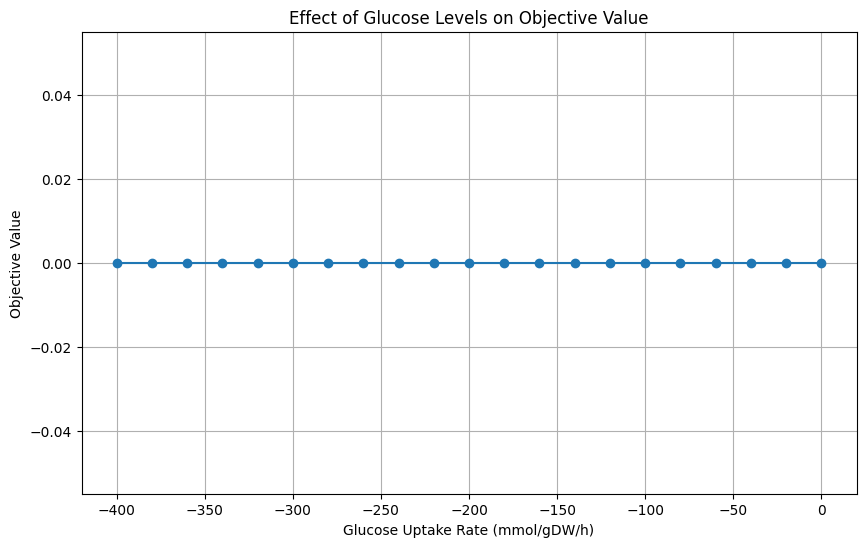

In [56]:

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(results_df["Glucose Level"], results_df["Objective Value"], marker='o')
plt.xlabel("Glucose Uptake Rate (mmol/gDW/h)")
plt.ylabel("Objective Value")
plt.title("Effect of Glucose Levels on Objective Value")
plt.grid(True)
plt.show()

In [57]:

# Display FVA results for a specific glucose level
# For example, display the FVA results at the first glucose level
print(f"FVA results at glucose level {results[0]['Glucose Level']}:")
print(results[0]['FVA'])

FVA results at glucose level -400:
                                 minimum       maximum
10FTHF7GLUtl                0.000000e+00   1666.666667
10FTHF7GLUtm                0.000000e+00   1666.666667
10FTHFtl                   -1.666667e+03      0.000000
10FTHFtm                   -1.000000e+04   2474.417677
13DAMPPOX                   7.750113e-36    492.165977
...                                  ...           ...
NCAMUP                      0.000000e+00  10000.000000
NCAMDe                      0.000000e+00  10000.000000
sink_ncam_LSQBKT_c_RSQBKT_ -6.521726e-02      0.019581
EX_pnto_R_LPAREN_e_RPAREN_ -3.171588e-01     -0.049167
DM_pnto_R                   4.916697e-02      0.317159

[2853 rows x 2 columns]


In [58]:
results[0]['FVA'].to_csv('FVA.csv')